# Machine Learning Lab 7 — Naive Bayes
## Spam Detection & Sentiment Analysis

**Student Name:** Muhammad Umar  
**Student ID:** 023-24-0260
**Section:** H  
**GitHub Profile:** https://github.com/muhammadumarofficial 
**Kaggle Profile:** https://www.kaggle.com/mohdumar10 


## 1. Problem Definition & Dataset Exploration

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

In [2]:
spam_path = r"C:\Users\umarc\Desktop\ML-Lab Practice\spam.csv"
tweets_path = r"C:\Users\umarc\Desktop\ML-Lab Practice\Tweets.csv"

spam = pd.read_csv(spam_path, encoding="latin-1")
tweets = pd.read_csv(tweets_path)

if "v1" in spam.columns and "v2" in spam.columns:
    spam = spam[["v1", "v2"]].rename(columns={
        "v1": "label",
        "v2": "message"
    })

print("SMS dataset shape:", spam.shape)
print("Twitter dataset shape:", tweets.shape)

display(spam.head())
display(tweets.head())


SMS dataset shape: (5572, 2)
Twitter dataset shape: (14640, 15)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### Task 1 — Interpretation

The SMS dataset contains 5,572 messages. Its two classes are ham and spam. The sentiment dataset contains 14,640 tweets originally; after removing neutral tweets as required by the lab, only positive and negative tweets are retained.

Both modeling tasks are binary classification because each prediction has exactly two possible classes after preprocessing: ham/spam for SMS and negative/positive for sentiment. fileciteturn0file0L78-L84

## 2. Task A — Cleaning & Vectorization (Spam)

For SMS messages, the cleaning is intentionally light. Lowercasing is enough for the main requirement, and extra preprocessing is kept limited because heavy NLP preprocessing is not the focus of this lab. TF-IDF is used to convert the messages into numerical features.

In [3]:
# Task 3 

def clean_sms(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

spam["clean_message"] = spam["message"].apply(clean_sms)

# Task 4 
spam["target"] = spam["label"].map({"ham": 0, "spam": 1})

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    spam["clean_message"],
    spam["target"],
    test_size=0.20,
    random_state=42,
    stratify=spam["target"]
)


vectorizer_a = TfidfVectorizer()
X_train_a_vec = vectorizer_a.fit_transform(X_train_a)
X_test_a_vec = vectorizer_a.transform(X_test_a)

print("Training rows:", X_train_a.shape[0])
print("Test rows:", X_test_a.shape[0])
print("Vocabulary size:", len(vectorizer_a.get_feature_names_out()))
print("Training matrix shape:", X_train_a_vec.shape)
print("Test matrix shape:", X_test_a_vec.shape)


Training rows: 4457
Test rows: 1115
Vocabulary size: 7701
Training matrix shape: (4457, 7701)
Test matrix shape: (1115, 7701)


### Task 4 — Why fit the vectorizer only on training data?

The vectorizer learns its vocabulary and IDF values from the data it is fitted on. If the full dataset were used before the train/test split, information from the test set would influence the learned representation, causing data leakage. Therefore, the vectorizer is fitted on training messages only and then used to transform the test messages. fileciteturn0file0L96-L105

## 3. Task A — Naive Bayes Model & Evaluation

,Metric,Score
0,Accuracy,0.9605
1,Precision,1.0000
2,Recall,0.7047
3,F1-score,0.8268


Confusion Matrix:
[[966   0]
 [ 44 105]]


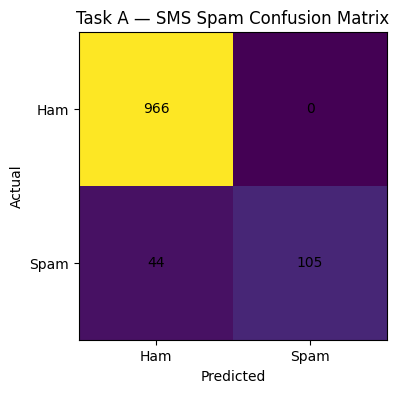

In [4]:
# Task 5 

nb_a = MultinomialNB()
nb_a.fit(X_train_a_vec, y_train_a)

pred_a = nb_a.predict(X_test_a_vec)

accuracy_a = accuracy_score(y_test_a, pred_a)
precision_a = precision_score(y_test_a, pred_a)
recall_a = recall_score(y_test_a, pred_a)
f1_a = f1_score(y_test_a, pred_a)

metrics_a = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy_a, precision_a, recall_a, f1_a]
})

display(metrics_a.style.format({"Score": "{:.4f}"}))

cm_a = confusion_matrix(y_test_a, pred_a)
print("Confusion Matrix:")
print(cm_a)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_a)
ax.set_title("Task A — SMS Spam Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Ham", "Spam"])
ax.set_yticklabels(["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_a[i, j], ha="center", va="center")

plt.show()


### Task 5 — Interpretation

The SMS Naive Bayes model achieved approximately **96.05% accuracy**, **100% precision**, **70.47% recall**, and **82.68% F1-score** on the test set. The confusion matrix shows that no ham messages were incorrectly classified as spam, while 44 spam messages were classified as ham.

This means the model was very conservative about calling a message spam: when it predicted spam, it was correct on this test set, but it still missed some actual spam messages.

### Task 6 — False Positive vs False Negative

For this application, a **false positive** can be especially harmful because a legitimate ham message could be incorrectly marked as spam and hidden from the user. A false negative lets a spam message reach the inbox, which is undesirable but usually does not remove a legitimate message. Therefore, for a system where protecting legitimate messages is the priority, I would prioritize **precision** while still monitoring recall. The current result supports this focus because precision is 1.00, although recall shows that some spam messages are still being missed. fileciteturn0file0L123-L128

## 4. Task A — Word Interpretation

In [5]:
# Task 7 

feature_names_a = vectorizer_a.get_feature_names_out()
log_probability_difference = nb_a.feature_log_prob_[1] - nb_a.feature_log_prob_[0]

spam_indices = np.argsort(log_probability_difference)[-15:][::-1]
ham_indices = np.argsort(log_probability_difference)[:15]

spam_words = pd.DataFrame({
    "Word": feature_names_a[spam_indices],
    "Log Probability Difference": log_probability_difference[spam_indices]
})

ham_words = pd.DataFrame({
    "Word": feature_names_a[ham_indices],
    "Log Probability Difference": log_probability_difference[ham_indices]
})

print("15 words most strongly associated with SPAM")
display(spam_words)

print("15 words most strongly associated with HAM")
display(ham_words)


15 words most strongly associated with SPAM


,Word,Log Probability Difference
0,claim,3.468134
1,prize,3.264996
2,150p,3.002480
3,www,2.999182
4,uk,2.898543
5,tone,2.862390
6,18,2.806324
7,guaranteed,2.786691
8,cs,2.749913
9,1000,2.728668


15 words most strongly associated with HAM


,Word,Log Probability Difference
0,gt,-3.206848
1,lt,-3.196134
2,my,-3.175403
3,ok,-3.136059
4,ll,-3.096899
5,later,-3.029956
6,lor,-2.971010
7,da,-2.933209
8,but,-2.863401
9,home,-2.859073


### Task 7 — Interpretation

The strongest spam-associated words include terms such as **claim, prize, 150p, guaranteed, nokia, 500, txt, and service**, which are reasonably consistent with promotional or prize-related SMS messages. The ham-associated words include conversational terms such as **my, ok, later, home, come, sorry, me, and how**, which fit ordinary personal messages.

Some short tokens such as `gt` and `lt` also appear because the model learns directly from the available text rather than understanding language semantically. This is an important limitation of simple bag-of-words style features.

In [6]:
# Task 8 

test_messages = [
    "Congratulations! You have won a free prize. Call now to claim your reward!",
    "Hi, I will reach the university at 10 am. Please bring the notes.",
    "URGENT! You have been selected for a cash prize. Reply now to receive it."
]

test_clean = [clean_sms(message) for message in test_messages]
test_vec = vectorizer_a.transform(test_clean)
test_predictions = nb_a.predict(test_vec)
test_probabilities = nb_a.predict_proba(test_vec)[:, 1]

custom_results = pd.DataFrame({
    "Message": test_messages,
    "Prediction": ["Spam" if p == 1 else "Ham" for p in test_predictions],
    "Spam Probability": test_probabilities
})

display(custom_results.style.format({"Spam Probability": "{:.4f}"}))


,Message,Prediction,Spam Probability
0,Congratulations! You have won a free prize. Call now to claim your reward!,Spam,0.9107
1,"Hi, I will reach the university at 10 am. Please bring the notes.",Ham,0.0153
2,URGENT! You have been selected for a cash prize. Reply now to receive it.,Spam,0.7669


### Task 8 — Interpretation

The first and third messages contain strong prize/urgent promotional language, so the model predicts spam. The normal university-related message is predicted as ham. These predictions match the expected labels and show how the learned word patterns can be used on new messages.

## 6. Task B — Cleaning & Vectorization (Sentiment)

In [7]:
# Task 11

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

tweets_binary["clean_text"] = tweets_binary["text"].apply(clean_tweet)
tweets_binary["target"] = tweets_binary["airline_sentiment"].map({
    "negative": 0,
    "positive": 1
})

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    tweets_binary["clean_text"],
    tweets_binary["target"],
    test_size=0.20,
    random_state=42,
    stratify=tweets_binary["target"]
)

vectorizer_b = TfidfVectorizer()
X_train_b_vec = vectorizer_b.fit_transform(X_train_b)
X_test_b_vec = vectorizer_b.transform(X_test_b)

print("Remaining sentiment rows:", len(tweets_binary))
print("Training rows:", X_train_b.shape[0])
print("Test rows:", X_test_b.shape[0])
print("Vocabulary size:", len(vectorizer_b.get_feature_names_out()))
print("Training matrix shape:", X_train_b_vec.shape)
print("Test matrix shape:", X_test_b_vec.shape)


NameError: name 'tweets_binary' is not defined

## 7. Task B — Naive Bayes Model & Evaluation

,Metric,Score
0,Accuracy,0.8311
1,Precision,1.0000
2,Recall,0.1755
3,F1-score,0.2986


Confusion Matrix:
[[1836    0]
 [ 390   83]]


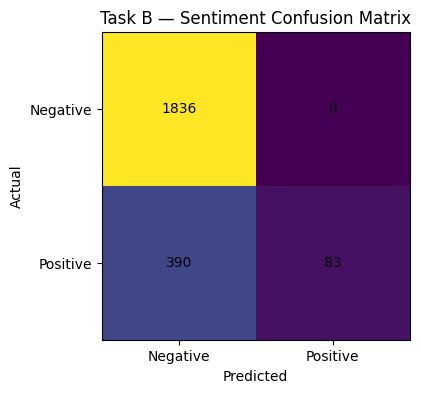

In [ ]:
# Task 13 — Multinomial Naive Bayes for sentiment

nb_b = MultinomialNB()
nb_b.fit(X_train_b_vec, y_train_b)

pred_b = nb_b.predict(X_test_b_vec)

accuracy_b = accuracy_score(y_test_b, pred_b)
precision_b = precision_score(y_test_b, pred_b)
recall_b = recall_score(y_test_b, pred_b)
f1_b = f1_score(y_test_b, pred_b)

metrics_b = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy_b, precision_b, recall_b, f1_b]
})

display(metrics_b.style.format({"Score": "{:.4f}"}))

cm_b = confusion_matrix(y_test_b, pred_b)
print("Confusion Matrix:")
print(cm_b)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_b)
ax.set_title("Task B — Sentiment Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Negative", "Positive"])
ax.set_yticklabels(["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_b[i, j], ha="center", va="center")

plt.show()


### Task 13 — Interpretation

The sentiment Naive Bayes model achieved approximately **83.11% accuracy**, but its recall for the positive class was only about **17.55%**, producing an F1-score of about **29.86%**. The confusion matrix shows that the model predicted many tweets as negative and missed a substantial number of positive tweets. Accuracy alone therefore does not describe the full behavior of this model.

### Task 14 — Comparison and the Naive Independence Assumption

Naive Bayes performed better on the SMS task than on the sentiment task using these settings. SMS messages are often short and formulaic, so individual words such as `prize`, `claim`, and `guaranteed` can be strong indicators of spam. Tweets are more context-dependent: negation such as “not good”, sarcasm, word combinations, and context can change the meaning of individual words. Treating each word as conditionally independent therefore gives Naive Bayes a harder problem on sentiment data, which is consistent with the lower recall and F1 observed here. fileciteturn0file0L186-L195

## 9. Cross-Task Comparison & Logistic Regression

In [ ]:
# Task 17

comparison_nb = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Task A — Spam": [accuracy_a, precision_a, recall_a, f1_a],
    "Task B — Sentiment": [accuracy_b, precision_b, recall_b, f1_b]
})

display(comparison_nb.style.format({
    "Task A — Spam": "{:.4f}",
    "Task B — Sentiment": "{:.4f}"
}))


,Metric,Task A — Spam,Task B — Sentiment
0,Accuracy,0.9605,0.8311
1,Precision,1.0000,1.0000
2,Recall,0.7047,0.1755
3,F1-score,0.8268,0.2986


### Task 17 — Interpretation

The side-by-side results show a clear difference between the two text problems. Naive Bayes achieved substantially stronger recall and F1 on spam detection than on sentiment analysis. This supports the idea that the same algorithm can behave differently depending on the structure and language characteristics of the task.

In [ ]:
# Task 18
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_a_vec, y_train_a)

pred_lr = logistic_model.predict(X_test_a_vec)

accuracy_lr = accuracy_score(y_test_a, pred_lr)
precision_lr = precision_score(y_test_a, pred_lr)
recall_lr = recall_score(y_test_a, pred_lr)
f1_lr = f1_score(y_test_a, pred_lr)

comparison_lr = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Naive Bayes": [accuracy_a, precision_a, recall_a, f1_a],
    "Logistic Regression": [accuracy_lr, precision_lr, recall_lr, f1_lr]
})

display(comparison_lr.style.format({
    "Naive Bayes": "{:.4f}",
    "Logistic Regression": "{:.4f}"
}))


,Metric,Naive Bayes,Logistic Regression
0,Accuracy,0.9605,0.9722
1,Precision,1.0000,0.9917
2,Recall,0.7047,0.7987
3,F1-score,0.8268,0.8848
